# Importing libraries

In [2]:
import subprocess
import sys, os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy import stats

* Helper functions

In [2]:
# Function to handle plotting with different array shapes
def safe_plot(ax, x, y, fmt, **kwargs):
    """Handle plotting with different array shapes.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to plot on
    x : numpy array
        x data which can be 1D or 2D
    y : numpy array
        y data which can be 1D or 2D
    fmt : str
        Format string for plot
    **kwargs : dict
        Additional keyword arguments for plot
    """
    # Function to ensure array is 1D
    def ensure_1d(arr):
        if arr is None:
            return None
        arr = np.asarray(arr)
        if arr.ndim == 2:
            if arr.shape[0] == 1:  # Row vector (1,n)
                return arr.flatten()
            elif arr.shape[1] == 1:  # Column vector (n,1)
                return arr.flatten()
        return arr
    
    x_1d = ensure_1d(x)
    y_1d = ensure_1d(y)
    return ax.plot(x_1d, y_1d, fmt, **kwargs)

* Figure 1

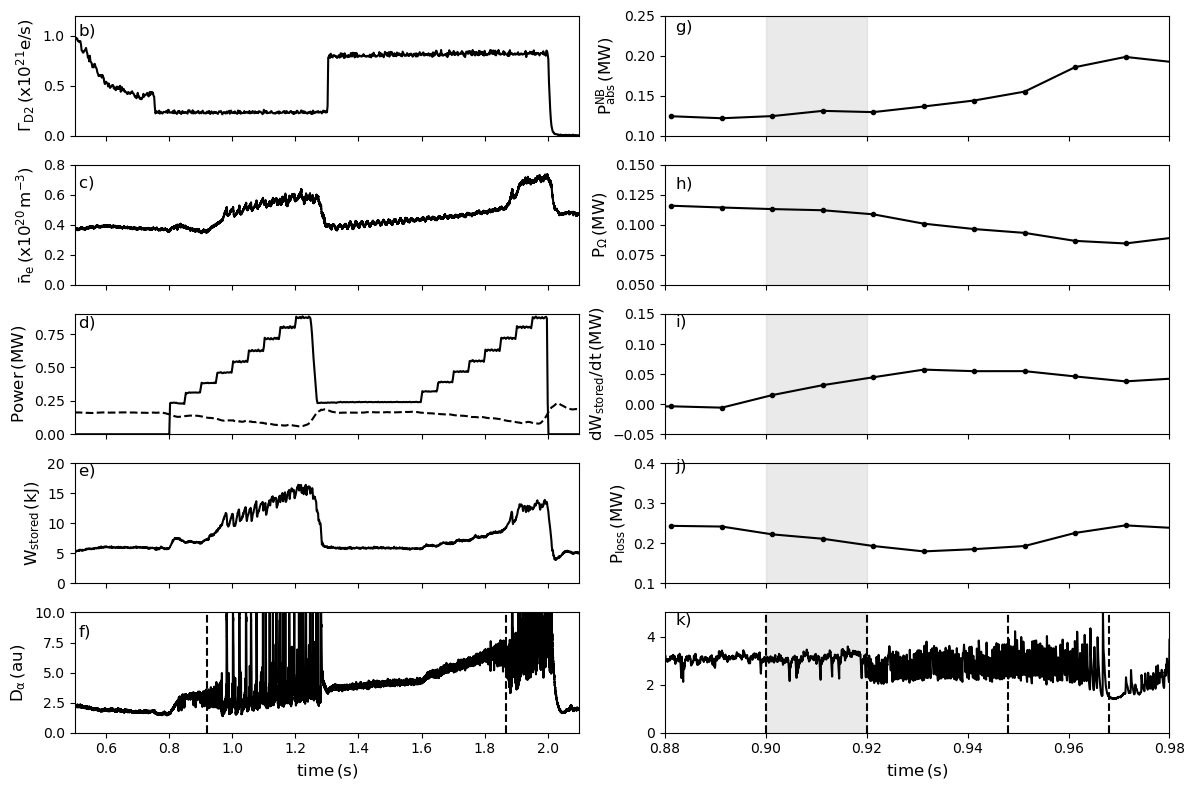

In [41]:
 # Load HDF5 data
    
with h5py.File('LH_DATA.h5', 'r') as f:
    O_data = f['/data/fig1']
    O = type('obj', (object,), {})
    for key in O_data.keys():
        setattr(O, key, np.array(O_data[key]))

shot = 68632
    
# Calculate Y values
Y1 = O.PNBABSTOT
Y3 = O.POHTOT
Y4 = (O.WEITOT + O.WFIPERP + O.WFILONG)
YY4 = O.dWdT

# Create figure
plt.figure(figsize=(12, 8))

# Set constants
smooth_tension = 1e-8
tm = 0.5
tM = 2.1

# Start creating the subplots
# subplot(5,2,5)
ax1 = plt.subplot(5, 2, 5)
# Handle boolean indexing for different array shapes
cond_tb = (O.tb.flatten() >= tm) & (O.tb.flatten() <= tM)
safe_plot(ax1, O.tb.flatten()[cond_tb], O.pnbi.flatten()[cond_tb]/1e6, 'k')
cond_to = (O.to.flatten() >= tm) & (O.to.flatten() <= tM)
safe_plot(ax1, O.to.flatten()[cond_to], O.pohm.flatten()[cond_to]/1e6, 'k--')
ax1.set_ylim([0, 0.9])
ax1.set_xlim([tm, tM])
ax1.set_ylabel(r'$\mathrm{Power\,(MW)}$', fontsize=12)
ax1.set_xticklabels([])
ax1.text(0.51, 0.8, r'$\mathrm{d)}$', fontsize=12)
plt.box(True)

# subplot(5,2,1)
ax2 = plt.subplot(5, 2, 1)
cond_tg = (O.tg.flatten() > tm) & (O.tg.flatten() < tM)
safe_plot(ax2, O.tg.flatten()[cond_tg], 2*O.g.flatten()[cond_tg]/1e21, 'k')
ax2.set_ylim([0, 1.2])
ax2.set_xlim([tm, tM])
ax2.set_ylabel(r'$\mathrm{\Gamma_{D2}\,(x10^{21} e/s)}$', fontsize=12)
ax2.set_xticklabels([])
ax2.text(0.51, 1, r'$\mathrm{b)}$', fontsize=12)

# subplot(5,2,3)
ax3 = plt.subplot(5, 2, 3)
cond_tnel = (O.tnel.flatten() > tm) & (O.tnel.flatten() < tM)
safe_plot(ax3, O.tnel.flatten()[cond_tnel], O.nel.flatten()[cond_tnel], 'k')
ax3.set_ylim([0, 0.8])
ax3.set_xlim([tm, tM])
ax3.set_xticklabels([])
ax3.set_ylabel(r'$\mathrm{\bar n_e\,(x10^{20}\,m^{-3})}$', fontsize=12)
ax3.text(0.51, 0.65, r'$\mathrm{c)}$', fontsize=12)

# subplot(5,2,7)
ax4 = plt.subplot(5, 2, 7)
cond_tw = (O.tw.flatten() >= tm) & (O.tw.flatten() <= tM)
safe_plot(ax4, O.tw.flatten()[cond_tw], O.wmhd.flatten()[cond_tw]/1e3, 'k')
ax4.set_ylabel(r'$\mathrm{W_{stored}\,(kJ)}$', fontsize=12)
ax4.set_ylim([0, 20])
ax4.set_xlim([tm, tM])
ax4.set_xticklabels([])
ax4.text(0.51, 18, r'$\mathrm{e)}$', fontsize=12)

# subplot(5,2,9)
ax5 = plt.subplot(5, 2, 9)
cond_pd = (O.pd_time.flatten() > tm) & (O.pd_time.flatten() < tM)
safe_plot(ax5, O.pd_time.flatten()[cond_pd], O.pd_data.flatten()[cond_pd], 'k')
tt = O.OUT_TIME[O.OUT_SHOT == shot]
ax5.plot([tt[0]+0.01, tt[0]+0.01], [0, 10], 'k--')
ax5.plot([tt[1]+0.01, tt[1]+0.01], [0, 10], 'k--')
ax5.set_xlabel(r'$\mathrm{time\, (s)}$', fontsize=12)
ax5.set_ylabel(r'$\mathrm{D_{\alpha}\,(au)}$', fontsize=12)
ax5.set_ylim([0, 10])
ax5.set_xlim([tm, tM])
ax5.text(0.51, 8, r'$\mathrm{f)}$', fontsize=12)

# Update time range for the next plots
tm = 0.88
tM = 0.98
tt = O.TIME[O.SHOT == shot]

# For 1×n arrays, flatten before boolean indexing
cond = (O.T.flatten() >= tm) & (O.T.flatten() <= tM+0.01)

# subplot(5,2,2)
ax6 = plt.subplot(5, 2, 2)
# Create a rectangle patch
rect = plt.Rectangle((tt[0]-0.01, 0.1), 0.02, 0.15, color=(0.8, 0.8, 0.8), alpha=0.4)
ax6.add_patch(rect)
safe_plot(ax6, O.X.flatten()[cond], Y1.flatten()[cond], '.-k')
ax6.set_ylim([0.1, 0.25])
ax6.set_xlim([tm, tM])
ax6.set_ylabel(r'$\mathrm{P_{abs}^{NB}\,(MW)}$', fontsize=12)
ax6.set_xticklabels([])
ax6.text(0.882, 0.23, r'$\mathrm{g)}$', fontsize=12)
plt.box(True)

# subplot(5,2,4)
ax7 = plt.subplot(5, 2, 4)
rect = plt.Rectangle((tt[0]-0.01, 0.05), 0.02, 0.1, color=(0.8, 0.8, 0.8), alpha=0.4)
ax7.add_patch(rect)
safe_plot(ax7, O.X.flatten()[cond], Y3.flatten()[cond], '.-k')
ax7.set_ylim([0.05, 0.15])
ax7.set_xlim([tm, tM])
ax7.set_xticklabels([])
ax7.set_ylabel(r'$\mathrm{P_{\Omega}\,(MW)}$', fontsize=12)
ax7.text(0.882, 0.13, r'$\mathrm{h)}$', fontsize=12)
plt.box(True)

# subplot(5,2,6)
ax8 = plt.subplot(5, 2, 6)
rect = plt.Rectangle((tt[0]-0.01, -0.05), 0.02, 0.2, color=(0.8, 0.8, 0.8), alpha=0.4)
ax8.add_patch(rect)
safe_plot(ax8, O.X.flatten(), YY4.flatten(), '.-k')
ax8.set_ylim([-0.05, 0.15])
ax8.set_xlim([tm, tM])
ax8.set_ylabel(r'$\mathrm{dW_{stored}/dt\,(MW)}$', fontsize=12)
ax8.set_xticklabels([])
ax8.text(0.882, 0.13, r'$\mathrm{i)}$', fontsize=12)
plt.box(True)

# subplot(5,2,8)
ax9 = plt.subplot(5, 2, 8)
rect = plt.Rectangle((tt[0]-0.01, 0.1), 0.02, 0.3, color=(0.8, 0.8, 0.8), alpha=0.4)
ax9.add_patch(rect)
# Make sure arrays are flattened before arithmetic operations
ploss = Y1.flatten()[cond] + Y3.flatten()[cond] - YY4.flatten()[cond]
safe_plot(ax9, O.X.flatten()[cond], ploss, '.-k')
ax9.set_ylabel(r'$\mathrm{P_{loss}\,(MW)}$', fontsize=12)
ax9.set_ylim([0.1, 0.4])
ax9.set_xlim([tm, tM])
ax9.set_xticklabels([])
ax9.text(0.882, 0.38, r'$\mathrm{j)}$', fontsize=12)
plt.box(True)

# subplot(5,2,10)
ax10 = plt.subplot(5, 2, 10)
cond_pd = (O.pd_time.flatten() > tm) & (O.pd_time.flatten() < tM)
rect = plt.Rectangle((tt[0]-0.01, 0), 0.02, 5, color=(0.8, 0.8, 0.8), alpha=0.4)
ax10.add_patch(rect)
safe_plot(ax10, O.pd_time.flatten()[cond_pd], O.pd_data.flatten()[cond_pd], 'k')
tt = O.OUT_TIME[O.OUT_SHOT == shot]
ax10.plot([tt[0]+0.01, tt[0]+0.01], [0, 5], 'k--')
ax10.plot([tt[0]-0.01, tt[0]-0.01], [0, 5], 'k--')
tt = O.OUT2_TIME[O.OUT2_SHOT == shot]
ax10.plot([tt[0]+0.01, tt[0]+0.01], [0, 10], 'k--')
ax10.plot([tt[0]-0.01, tt[0]-0.01], [0, 10], 'k--')
ax10.set_xlabel(r'$\mathrm{time\, (s)}$', fontsize=12)
ax10.set_ylim([0, 5])
ax10.set_xlim([tm, tM])
ax10.text(0.882, 4.5, r'$\mathrm{k)}$', fontsize=12)
plt.box(True)

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()

* Figure 2

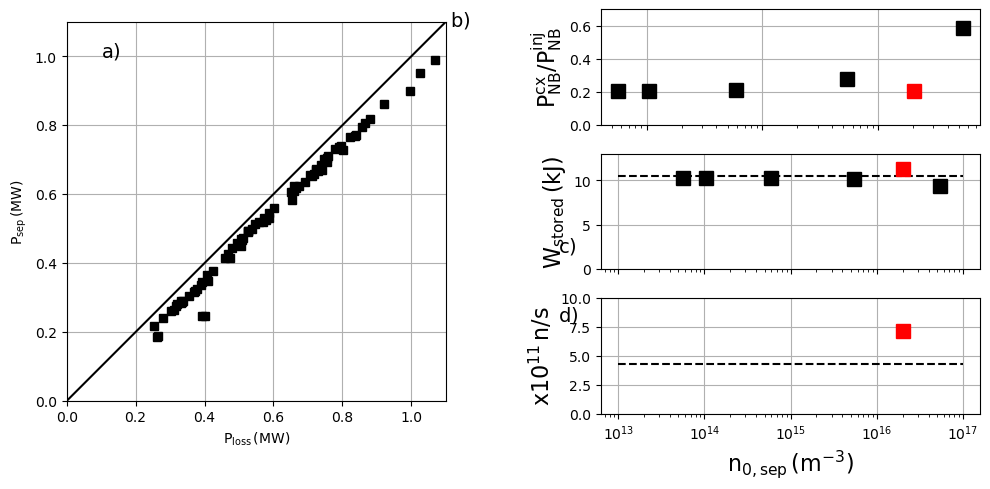

In [36]:
with h5py.File('LH_DATA.h5', 'r') as f:
    O_data = f['/data/fig2']
    O = type('obj', (object,), {})
    for key in O_data.keys():
        setattr(O, key, np.array(O_data[key]))

shot = 68632

# Create condition for data selection (example condition)
cond = O.PLMW > 0.2

# Constants
time = O.OUT_TIME[O.OUT_SHOT == 76239][0]

# Create figure with specific size
plt.figure(figsize=(10, 5))

# First subplot: P_sep vs P_loss
ax1 = plt.subplot(1, 2, 1)
ax1.plot(O.PLMW[cond], O.PSEP[cond], 'sk', markerfacecolor='k')
ax1.plot([0, 1.1], [0, 1.1], 'k')
ax1.set_aspect('equal', 'box')
ax1.set_xlim([0, 1.1])
ax1.set_ylim([0, 1.1])
ax1.grid(True)
ax1.set_xlabel(r'$\mathrm{P_{loss}\,(MW)}$')
ax1.set_ylabel(r'$\mathrm{P_{sep}\,(MW)}$')
ax1.text(0.1, 1, r'$\mathrm{a)}$', fontsize=14)

# Second subplot: Charge exchange ratio
ax2 = plt.subplot(3, 2, 2)
ax2.semilogx(O.n0sep_1, O.cx, 'sk', markersize=10, markerfacecolor='k')
tmp = np.mean(O.BPCXI + O.BPCXX)
ax2.semilogx(O.DN0, tmp * np.ones_like(O.DN0), 'rs', markerfacecolor='r', markersize=10)
ax2.set_xticklabels([])
ax2.grid(True)
ax2.set_ylabel(r'$\mathrm{P_{NB}^{cx}/P_{NB}^{inj}}$', fontsize=16)
ax2.set_ylim([0, 0.7])
ax2.text(2e12, 0.6, r'$\mathrm{b)}$', fontsize=14)

# Third subplot: Stored energy
ax3 = plt.subplot(3, 2, 4)
ax3.semilogx(O.n0sep_2, O.wtot * 1e3, 'sk', markersize=10, markerfacecolor='k')
x_wexp = np.array([1e13, 1e17])  # Ensure 1D
y_wexp = np.ones_like(x_wexp) * (O.wexp * 1e-3)  # Ensure same shape as x_wexp
ax3.semilogx(x_wexp.flatten(), y_wexp.flatten(), 'k--')
ax3.semilogx(O.DN0, O.UTOTLT/1e3, 'sr', markerfacecolor='r', markersize=10)
ax3.set_ylabel(r'$\mathrm{W_{stored}\,(kJ)}$', fontsize=16)
ax3.set_xticklabels([])
ax3.set_ylim([0, 13])
ax3.grid(True)
ax3.text(2e12, 2, r'$\mathrm{c)}$', fontsize=14)

# Fourth subplot: Particle numbers
ax4 = plt.subplot(3, 2, 6)
x_wexp = np.array([1e13, 1e17])  # Ensure 1D
y_nlupin = np.ones_like(x_wexp) * (O.Nlupin / 1e11)
ax4.semilogx(x_wexp.flatten(), y_nlupin.flatten(), 'k--')
ax4.semilogx(O.DN0, O.Ntransp / 1e11, 'sr', markerfacecolor='r', markersize=10)
ax4.set_ylim([0, 10])
ax4.set_xlabel(r'$\mathrm{n_{0,sep}\,(m^{-3})}$', fontsize=16)
ax4.set_ylabel(r'$\mathrm{x10^{11}\, n/s}$', fontsize=16)
ax4.grid(True)
ax4.text(2e12, 8, r'$\mathrm{d)}$', fontsize=14)

# Adjust layout for better spacing
plt.tight_layout()

# Display the figure
plt.show()

* Figure 3

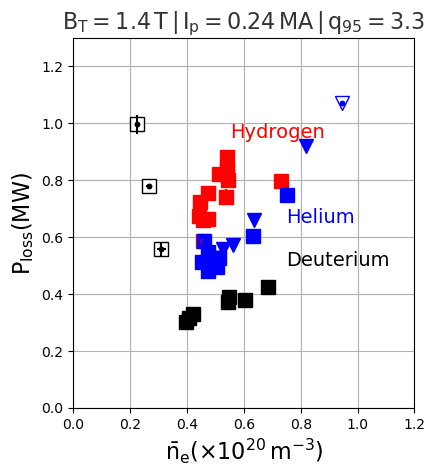

In [3]:
# Load data
filename = 'lhdatabase.h5'
with h5py.File(filename, 'r') as f:
    Q95 = f['/Q95'][:]
    ILH = f['/ILH'][:].astype(bool)
    A = f['/A'][:]
    SEEDING = f['/SEEDING'][:]
    PECH = f['/PECH'][:]
    cH = f['/cH'][:]
    NEL20 = f['/NEL20'][:]
    NEL20STD = f['/NEL20STD'][:]
    PLMW = f['/PLMW'][:]
    PLMWSTD = f['/PLMWSTD'][:]
    ABEAM = f['/ABEAM'][:]
    CFI_A = f['/CFI_A'][:]
    SHOT = f['/SHOT'][:]

# Helper function for horizontal error bars
def herrorbar(x, y, xerr, fmt, **kwargs):
    plt.errorbar(x, y, xerr=xerr, fmt=fmt, **kwargs)

# Plotting
plt.figure()
plt.grid(True)
plt.box(True)

# Condition 1
cond = (Q95 < 3.5) & ILH & (A == 2) & (SEEDING == 0) & (PECH >= 0) & (cH < 0.26)
plt.plot(NEL20[cond], PLMW[cond], 'sk', markerfacecolor='k', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.k')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.k')

# Condition 2
cond = (Q95 < 3.5) & (~ILH) & (A == 2) & (SEEDING == 0) & (PECH >= 0) & (cH < 0.26)
plt.plot(NEL20[cond], PLMW[cond], 'sk', markerfacecolor='w', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.k')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.k')

# Condition 3
cond = (Q95 < 3.5) & ILH & (A == 1) & (cH > 0.8) & (SEEDING == 0)
plt.plot(NEL20[cond], PLMW[cond], 'sr', markerfacecolor='r', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.r')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.r')

# Condition 4
cond = (Q95 < 3.5) & (~ILH) & (A == 1) & (cH > 0.8) & (SEEDING == 0)
plt.plot(NEL20[cond], PLMW[cond], 'sr', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.r')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.r')

# Condition 5
cond = (Q95 < 3.5) & ILH & (A == 4) & (SEEDING == 0) & (ABEAM == 2) & (CFI_A < 0.2)
plt.plot(NEL20[cond], PLMW[cond], 'sb', markerfacecolor='b', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.b')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.b')

# Condition 6
cond = (Q95 < 3.5) & (~ILH) & (A == 4) & (SEEDING == 0) & (ABEAM == 2) & (CFI_A < 0.2)
plt.plot(NEL20[cond], PLMW[cond], 'sb', markerfacecolor='w', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.b')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.b')
for x, y, s in zip(NEL20[cond] + 0.02, PLMW[cond], SHOT[cond]):
    plt.text(x, y, str(int(s)), fontsize=6, color=(0.2, 0.2, 0.2))

# Condition 7
cond = (Q95 < 3.5) & ILH & (A == 4) & (SEEDING == 0) & (ABEAM == 1) & (CFI_A < 0.2)
plt.plot(NEL20[cond], PLMW[cond], 'vb', markerfacecolor='b', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.b')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.b')

# Condition 8
cond = (Q95 < 3.5) & (~ILH) & (A == 4) & (SEEDING == 0) & (ABEAM == 1) & (CFI_A < 0.2)
plt.plot(NEL20[cond], PLMW[cond], 'vb', markerfacecolor='w', markersize=10)
herrorbar(NEL20[cond], PLMW[cond], NEL20STD[cond], '.b')
plt.errorbar(NEL20[cond], PLMW[cond], yerr=PLMWSTD[cond], fmt='.b')

# Labels and title
plt.xlabel(r'$\mathrm{\bar{n}_{e} (\times 10^{20}\,m^{-3})}$', fontsize=16)
plt.ylabel(r'$\mathrm{P_{loss} (MW)}$', fontsize=16)
plt.xlim([0, 1.2])
plt.ylim([0, 1.3])
plt.title(r'$\mathrm{B_{T}=1.4\,T\,|\,I_{p}=0.24\,MA\,|\,q_{95}=3.3}$', fontsize=16, color=(.2, .2, .2))
plt.text(0.75, 0.5, 'Deuterium', color='k', fontsize=14)
plt.text(0.75, 0.65, 'Helium', color='b', fontsize=14)
plt.text(0.55, 0.95, 'Hydrogen', color='r', fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


* Figure 4

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


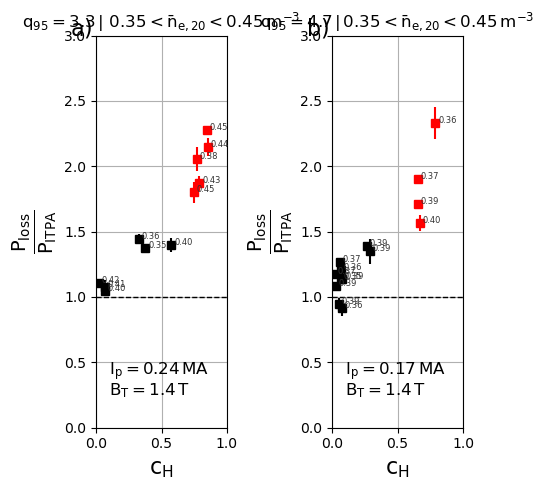

In [4]:
# Read data from HDF5 file
filename = 'lhdatabase.h5'
with h5py.File(filename, 'r') as f:
    Q95 = f['/Q95'][:]
    ILH = f['/ILH'][:].astype(bool)
    A = f['/A'][:]
    SEEDING = f['/SEEDING'][:]
    PECH = f['/PECH'][:]
    cH = f['/cH'][:]
    NEL20 = f['/NEL20'][:]
    NEL20STD = f['/NEL20STD'][:]
    PLMW = f['/PLMW'][:]
    PLMWSTD = f['/PLMWSTD'][:]
    ABEAM = f['/ABEAM'][:]
    CFI_A = f['/CFI_A'][:]
    SHOT = f['/SHOT'][:]
    BT = f['/BT'][:]
    SPLASMA = f['/SPLASMA'][:]
    HDRSTD = f['/HDRSTD'][:]

P1 = 0.049 * np.abs(NEL20)**0.72 * np.abs(BT)**0.8 * SPLASMA**0.94

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
X = []
Y = []

# Helper function for plotting with conditions
def plot_condition(ax, cond, marker, facecolor=None, label=None):
    x = cH[cond]
    y = PLMW[cond] / P1[cond]
    yerr = PLMWSTD[cond] / P1[cond]
    ax.errorbar(x, y, yerr=yerr, fmt=marker, mfc=facecolor, label=label)
    for i, txt in enumerate(NEL20[cond]):
        ax.text(x[i]+0.02, y[i], f'{txt:.2f}', fontsize=6, color=(.2, .2, .2))
    return list(x), list(y)

# First subplot
ax = axes[0]
conditions = [
    (ILH & (SEEDING==0) & (PECH==0) & (Q95<3.5) & (ABEAM==2) & (A==2) & (NEL20>0.35) & (NEL20<0.45), 'sk', 'k'),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95<3.5) & (ABEAM==2) & (A==1) & (NEL20>0.35) & (NEL20<0.45), 'ok', None),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95<3.5) & (ABEAM==1) & (A==1) & (NEL20>0.35) & (NEL20<0.45), 'sr', 'r'),
    (~ILH & (SEEDING==0) & (PECH==0) & (Q95<3.5) & (ABEAM==1) & (A==1) & (NEL20>0.35) & (NEL20<0.45), 'sr', None),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95<3.5) & (ABEAM==1) & (A==2) & (NEL20>0.35) & (NEL20<0.45), 'or', None),
]

for cond, marker, face in conditions:
    x, y = plot_condition(ax, cond, marker, face)
    X += x
    Y += y

ax.plot([0, 1], [1, 1], 'k--', linewidth=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 3])
ax.set_xlabel(r'$\mathrm{c_H}$', fontsize=16)
ax.set_ylabel(r'$\mathrm{\frac{P_{loss}}{P_{ITPA}}}$', fontsize=20)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title(r'$\mathrm{q_{95}=3.3\,|\,\,0.35<\bar n_{e,20}<0.45\,m^{-3}}$', fontsize=12)
ax.text(0.1, 0.4, r'$\mathrm{I_p=0.24\,MA}$', fontsize=12)
ax.text(0.1, 0.25, r'$\mathrm{B_T=1.4\,T}$', fontsize=12)

# Placeholder for nonlinear regression
# BETA = nonlinreg(np.array(X), np.array(Y) - 1)
# Yreg = param_scaling(BETA, np.linspace(0, 1, 21))
# ax.plot(np.linspace(0, 1, 21), Yreg + 1, 'k')
# ax.text(0.1, 2.6, rf'$y = {BETA[1]:.2f}x^{{{BETA[0]:.2f}}}+1$', fontsize=12)
ax.text(-0.2, 3, r'$\mathrm{a)}$', fontsize=16)

# Second subplot
ax = axes[1]
X = []
Y = []

conditions = [
    (ILH & (SEEDING==0) & (PECH==0) & (Q95>4) & (Q95<5) & (ABEAM==2) & (A==2) & (NEL20>0.35) & (NEL20<0.45), 'sk', 'k'),
    (~ILH & (SEEDING==0) & (PECH==0) & (Q95>4) & (Q95<5) & (ABEAM==2) & (A==2) & (NEL20>0.35) & (NEL20<0.45), 'sk', None),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95>4) & (Q95<5) & (ABEAM==2) & (A==1) & (NEL20>0.35) & (NEL20<0.45), 'vr', 'r'),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95>4) & (Q95<5) & (ABEAM==1) & (A==1) & (NEL20>0.35) & (NEL20<0.45), 'sr', 'r'),
    (ILH & (SEEDING==0) & (PECH==0) & (Q95>4) & (Q95<5) & (ABEAM==1) & (A==2) & (NEL20>0.35) & (NEL20<0.45), 'ok', 'k')
]

for cond, marker, face in conditions:
    x, y = plot_condition(ax, cond, marker, face)
    X += x
    Y += y
    if marker == 'ok':  # Extra horizontal error bars for the last condition
        ax.errorbar(
            cH[cond], PLMW[cond], xerr=HDRSTD[cond], fmt='r.', label='_nolegend_'
        )

ax.plot([0, 1], [1, 1], 'k--', linewidth=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 3])
ax.set_xlabel(r'$\mathrm{c_H}$', fontsize=16)
ax.set_ylabel(r'$\mathrm{\frac{P_{loss}}{P_{ITPA}}}$', fontsize=20)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title(r'$\mathrm{q_{95}=4.7\,|\,0.35<\bar n_{e,20}<0.45\,m^{-3}}$', fontsize=12)
ax.text(0.1, 0.4, r'$\mathrm{I_p=0.17\,MA}$', fontsize=12)
ax.text(0.1, 0.25, r'$\mathrm{B_T=1.4\,T}$', fontsize=12)

# Placeholder for nonlinear regression
# BETA = nonlinreg(np.array(X), np.array(Y) - 1)
# Yreg = param_scaling(BETA, np.linspace(0, 1, 21))
# ax.plot(np.linspace(0, 1, 21), Yreg + 1, 'k')
# ax.text(0.1, 2.6, rf'$y = {BETA[1]:.2f}x^{{{BETA[0]:.2f}}}+1$', fontsize=12)
ax.text(-0.2, 3, r'$\mathrm{b)}$', fontsize=16)


plt.tight_layout()
plt.show()


* Figure 5

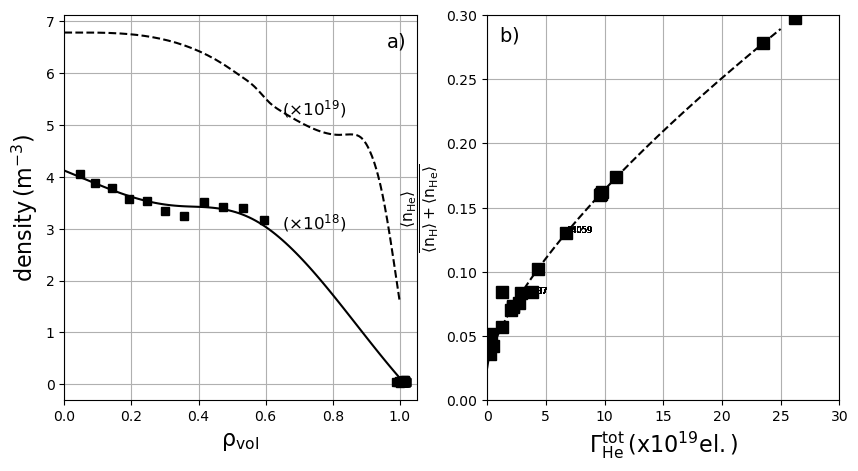

In [10]:
# Define shot numbers and times
shn = np.array([69891, 69891, 69892, 69892, 69895, 69895, 69896])
time = np.array([1.174, 1.960, 1.206, 1.838, 1.117, 1.876, 1.134])

# Load data
with h5py.File('LH_DATA.h5', 'r') as f:
    O_data = f['/data/fig5']
    O = type('obj', (object,), {})
    for key in O_data.keys():
        setattr(O, key, np.array(O_data[key]))

# Create figure
plt.figure(figsize=(10, 5))

# Define indices for subplot
im = [1, 0, 2, 0, 5, 0, 6]

# First subplot
plt.subplot(1, 2, 1)
# Loop through each 'out' index and create plots
# for i in range(0, 3):
plt.plot(O.out_rhopsi, O.out_nHe/1e18, 'sk', markersize=6, markerfacecolor='k')
plt.plot(O.out_rhopsii, O.out_nHei/1e18, 'k')
plt.plot(O.out_rhoneft.T, O.out_neft.T/1e19, '--k')
plt.xlabel(r'$\mathrm{\rho_{vol}}$', fontsize=16)
plt.ylabel(r'$\mathrm{density\,(m^{-3})}$', fontsize=16)
plt.text(0.65, 5.2, r'$\mathrm{(\times 10^{19})}$', fontsize=12)
plt.text(0.65, 3, r'$\mathrm{(\times 10^{18})}$', fontsize=12)
plt.xlim([0, 1.05])
plt.ylim([0, 8.0])
plt.autoscale(False)  
plt.grid(True)
# Make the plot square
#plt.axis('square')
plt.text(0.96, 6.5, r'$\mathrm{a)}$', fontsize=14)

# Second subplot
plt.subplot(1, 2, 2)
plt.plot(O.HETOT.flatten()/1e19, O.ci2.flatten(), 'sk', markersize=8, markerfacecolor='k')
plt.plot(O.tmpHETOT.flatten(), O.cHe.flatten(), 'sk', markersize=8, markerfacecolor='none')
plt.plot(O.gi.flatten(), O.ci.flatten(), '--k')
plt.xlabel(r'$\mathrm{\Gamma_{He}^{tot}\,(x10^{19} el.)}$', fontsize=16)
plt.ylabel(r'$\mathrm{\frac{\langle n_{He}\rangle}{\langle n_H\rangle+\langle n_{He}\rangle}}$', fontsize=16)
plt.xlim([0, 30])
plt.ylim([0, 0.3])
plt.autoscale(False)  

# Add text labels for shot numbers
for i, (x, y) in enumerate(zip(O.HETOT.flatten()[O.cond.flatten()]/1e19, O.ci2.flatten()[O.cond.flatten()])):
    plt.text(x, y, str(int(O.SHOT.flatten()[O.cond.flatten()][i])), fontsize=6)

#plt.axis('square')
plt.grid(True)
plt.text(1, 0.28, r'$\mathrm{b)}$', fontsize=14)

# Adjust layout and show plot
# plt.tight_layout()
plt.show()

* Figure 6

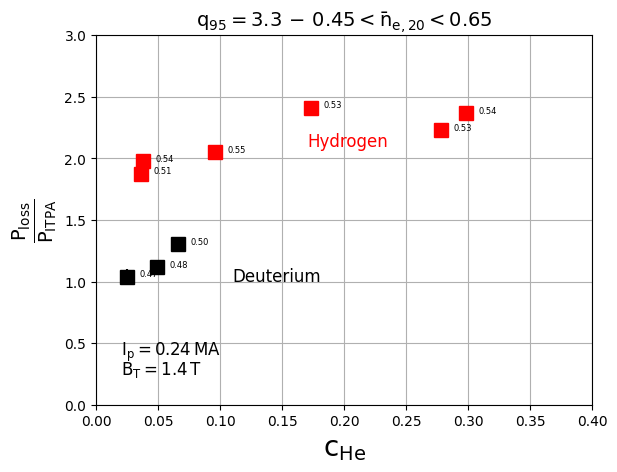

In [45]:
# Load data
filename = 'lhdatabase.h5'
with h5py.File(filename, 'r') as f:
    Q95 = np.array(f['/Q95'])
    ILH = np.array(f['/ILH'])
    A = np.array(f['/A'])
    SEEDING = np.array(f['/SEEDING'])
    cH = np.array(f['/cH'])
    NEL20 = np.array(f['/NEL20'])
    PLMW = np.array(f['/PLMW'])
    PLMWSTD = np.array(f['/PLMWSTD'])
    BT = np.array(f['/BT'])
    SPLASMA = np.array(f['/SPLASMA'])
    cHe = np.array(f['/cHe'])

# Compute P1
P1 = 0.049 * np.abs(NEL20)**0.72 * np.abs(BT)**0.8 * SPLASMA**0.94

# Plot
plt.figure()
plt.grid(True)
plt.box(True)

# First condition: Deuterium
cond = (A == 2) & (ILH != 0) & (cH < 0.3) & (Q95 < 3.5) & (SEEDING == 1)
cond &= (NEL20 > 0.45) & (NEL20 < 0.55)

plt.plot(cHe[cond], PLMW[cond]/P1[cond], 'sk', markerfacecolor='k', markersize=10)
plt.errorbar(cHe[cond], PLMW[cond]/P1[cond], yerr=PLMWSTD[cond]/P1[cond], fmt='.k')
for x, y, n in zip(cHe[cond], PLMW[cond]/P1[cond], NEL20[cond]):
    plt.text(x + 0.01, y, f'{n:.2f}', fontsize=6)

# Second condition: Hydrogen
cond = (A == 1) & (cH > 0.8) & (Q95 < 3.5) & (ILH != 0) & (SEEDING == 1)
cond &= (NEL20 > 0.5) & (NEL20 < 0.55)

plt.plot(cHe[cond], PLMW[cond]/P1[cond], 'sr', markerfacecolor='r', markersize=10)
plt.errorbar(cHe[cond], PLMW[cond]/P1[cond], yerr=PLMWSTD[cond]/P1[cond], fmt='.r')
for x, y, n in zip(cHe[cond], PLMW[cond]/P1[cond], NEL20[cond]):
    plt.text(x + 0.01, y, f'{n:.2f}', fontsize=6)

# Labels and title
plt.xlabel(r'$\mathrm{c_{He}}$', fontsize=20)
plt.ylabel(r'$\mathrm{\frac{P_{loss}}{P_{ITPA}}}$', fontsize=20)
plt.xlim([0, 0.4])
plt.ylim([0, 3])
plt.title(r'$\mathrm{q_{95}=3.3\,-\,0.45< \bar n_{e,20}< 0.65}$', fontsize=14)
plt.text(0.02, 0.4, r'$\mathrm{I_p=0.24\,MA}$', fontsize=12)
plt.text(0.02, 0.25, r'$\mathrm{B_T=1.4\,T}$', fontsize=12)
plt.text(0.17, 2.1, 'Hydrogen', fontsize=12, color='r')
plt.text(0.11, 1, 'Deuterium', fontsize=12, color='k')

plt.show()

* Figure 7

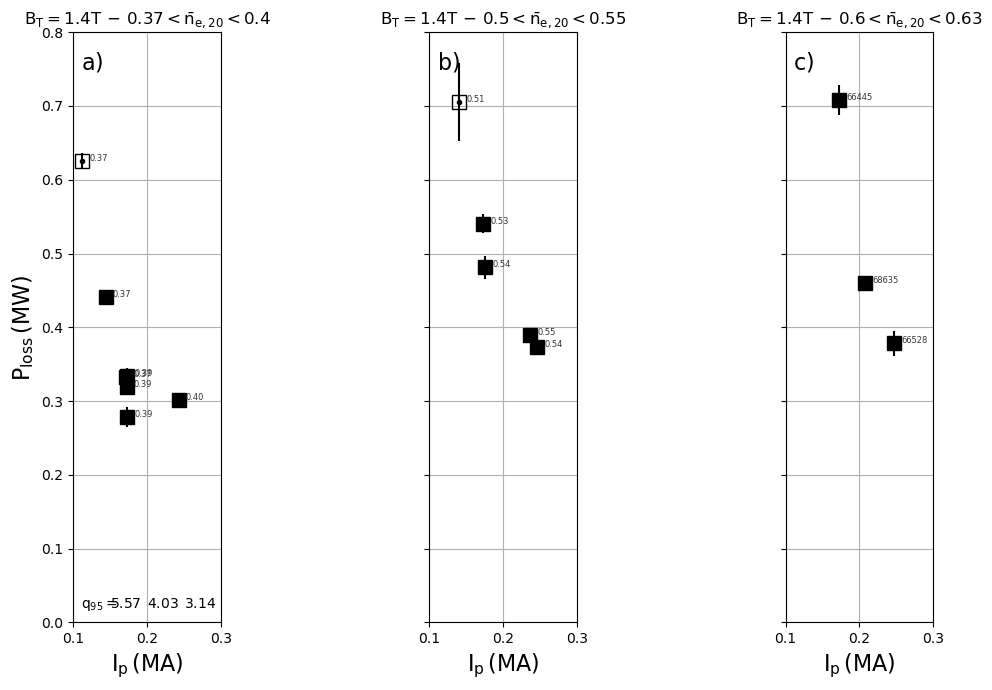

In [31]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# File name
filename = 'lhdatabase.h5'

# Read data from HDF5 file
with h5py.File(filename, 'r') as f:
    # Load all required datasets
    Q95 = np.array(f['/Q95']).flatten()
    ILH = np.array(f['/ILH']).astype(bool).flatten()
    A = np.array(f['/A']).flatten()
    SEEDING = np.array(f['/SEEDING']).flatten()
    PECH = np.array(f['/PECH']).flatten()
    cH = np.array(f['/cH']).flatten()
    NEL20 = np.array(f['/NEL20']).flatten()
    NEL20STD = np.array(f['/NEL20STD']).flatten()
    PLMW = np.array(f['/PLMW']).flatten()
    PLMWSTD = np.array(f['/PLMWSTD']).flatten()
    ABEAM = np.array(f['/ABEAM']).flatten()
    CFI_A = np.array(f['/CFI_A']).flatten()
    SHOT = np.array(f['/SHOT']).flatten()
    BT = np.array(f['/BT']).flatten()
    SPLASMA = np.array(f['/SPLASMA']).flatten()
    HDRSTD = np.array(f['/HDRSTD']).flatten()
    IP = np.array(f['/IP']).flatten()
    BAFFLES = np.array(f['/BAFFLES']).flatten()

# Create figure
plt.figure(figsize=(12, 7))

########## FIRST SUBPLOT ##########
plt.subplot(1, 3, 1)

# Identify points for the first subplot
x_vals = []
y_vals = []
y_errs = []
labels = []
is_ilh = []  # True if ILH is True, False otherwise

for i in range(len(IP)):
    # Check if this point meets the first subplot criteria
    if (A[i] == 2 and SEEDING[i] == 0 and BAFFLES[i] == 0 and
        NEL20[i] > 0.37 and NEL20[i] < 0.4 and cH[i] < 0.26):
        x_vals.append(IP[i])
        y_vals.append(PLMW[i])
        y_errs.append(PLMWSTD[i])
        labels.append(f"{NEL20[i]:.2f}")
        is_ilh.append(ILH[i])

# Now plot each point separately
if x_vals:
    # Find the highest y-value among ILH=True points
    ilh_true_indices = [i for i, ilh in enumerate(is_ilh) if ilh]
    
    if ilh_true_indices:  # If we have any ILH=True points
        max_plmw_idx = ilh_true_indices[np.argmax([y_vals[i] for i in ilh_true_indices])]
        
        # Plot each point
        for i in range(len(x_vals)):
            # Special case: highest ILH=True point gets unfilled square
            if i == 5: #max_plmw_idx:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='none')
            # ILH=True points (except highest) get filled square
            elif is_ilh[i]:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='k')
            # ILH=False points get unfilled square
            else:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='k')
        
        # Add error bars
        plt.errorbar(x_vals, y_vals, yerr=y_errs, fmt='.k')
        
        # Add text labels
        for i in range(len(x_vals)):
            plt.text(x_vals[i] + 0.01, y_vals[i], labels[i], fontsize=6, color=[0.2, 0.2, 0.2])

# Set labels and formatting
plt.xlabel(r'$\mathrm{I_p\,(MA)}$', fontsize=16)
plt.ylabel(r'$\mathrm{P_{loss}\,(MW)}$', fontsize=16)
plt.axis('square')
plt.grid(True)
plt.xlim([0.1, 0.3])
plt.ylim([0.0, 0.8])
plt.title(r'$\mathrm{B_T=1.4T\,-\,0.37<\bar{n}_{e,20}<0.4}$', fontsize=12)
plt.text(0.11, 0.75, r'$\mathrm{a)}$', fontsize=16)
plt.text(0.11, 0.02, r'$\mathrm{q_{95}=}$', fontsize=10)

# Calculate polynomial fit for q95
p = np.polyfit(IP, np.abs(Q95), 3)

# Add q95 values text
tmp = f"{np.polyval(p, 0.15):.2f}"
plt.text(0.15, 0.02, r'$\mathrm{' + tmp + '}$', fontsize=10)

tmp = f"{np.polyval(p, 0.2):.2f}"
plt.text(0.2, 0.02, r'$\mathrm{' + tmp + '}$', fontsize=10)

tmp = f"{np.polyval(p, 0.25):.2f}"
plt.text(0.25, 0.02, r'$\mathrm{' + tmp + '}$', fontsize=10)

########## SECOND SUBPLOT ##########
plt.subplot(1, 3, 2)

# Identify points for the second subplot
x_vals = []
y_vals = []
y_errs = []
labels = []
is_ilh = []  # True if ILH is True, False otherwise

for i in range(len(IP)):
    # Check if this point meets the second subplot criteria
    if (A[i] == 2 and SEEDING[i] == 0 and BAFFLES[i] == 0 and
        NEL20[i] > 0.5 and NEL20[i] < 0.55):
        x_vals.append(IP[i])
        y_vals.append(PLMW[i])
        y_errs.append(PLMWSTD[i])
        labels.append(f"{NEL20[i]:.2f}")
        is_ilh.append(ILH[i])

# Now plot each point separately
if x_vals:
    # Find the highest y-value among ILH=True points
    ilh_true_indices = [i for i, ilh in enumerate(is_ilh) if ilh]
    
    if ilh_true_indices:  # If we have any ILH=True points
        max_plmw_idx = ilh_true_indices[np.argmax([y_vals[i] for i in ilh_true_indices])]
        
        # Plot each point
        for i in range(len(x_vals)):
            # Special case: highest ILH=True point gets unfilled square
            if i == 4:# max_plmw_idx:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='none')
            # ILH=True points (except highest) get filled square
            elif is_ilh[i]:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='k')
            # ILH=False points get unfilled square
            else:
                plt.plot(x_vals[i], y_vals[i], 'sk', markersize=10, markerfacecolor='k')
        
        # Add error bars
        plt.errorbar(x_vals, y_vals, yerr=y_errs, fmt='.k')
        
        # Add text labels
        for i in range(len(x_vals)):
            plt.text(x_vals[i] + 0.01, y_vals[i], labels[i], fontsize=6, color=[0.2, 0.2, 0.2])

# Set labels and formatting
plt.xlabel(r'$\mathrm{I_p\,(MA)}$', fontsize=16)
plt.axis('square')
plt.grid(True)
plt.xlim([0.1, 0.3])
plt.ylim([0.0, 0.8])
plt.title(r'$\mathrm{B_T=1.4T\,-\,0.5<\bar{n}_{e,20}<0.55}$', fontsize=12)
plt.text(0.11, 0.75, r'$\mathrm{b)}$', fontsize=16)
plt.gca().set_yticklabels([])  # Remove y-axis tick labels

########## THIRD SUBPLOT ##########
plt.subplot(1, 3, 3)

# Identify points for the third subplot
x_vals_ilh_true = []
y_vals_ilh_true = []
y_errs_ilh_true = []
labels_ilh_true = []

x_vals_ilh_false = []
y_vals_ilh_false = []
y_errs_ilh_false = []
labels_ilh_false = []

for i in range(len(IP)):
    # Check if this point meets the third subplot criteria for ILH=True
    if (A[i] == 2 and SEEDING[i] == 0 and ILH[i] and BAFFLES[i] == 0 and
        NEL20[i] > 0.55 and NEL20[i] < 0.65):
        x_vals_ilh_true.append(IP[i])
        y_vals_ilh_true.append(PLMW[i])
        y_errs_ilh_true.append(PLMWSTD[i])
        labels_ilh_true.append(f"{int(SHOT[i])}")
    
    # Check if this point meets the third subplot criteria for ILH=False
    if (A[i] == 2 and SEEDING[i] == 0 and not ILH[i] and BAFFLES[i] == 0 and
        NEL20[i] > 0.58 and NEL20[i] < 0.63):
        x_vals_ilh_false.append(IP[i])
        y_vals_ilh_false.append(PLMW[i])
        y_errs_ilh_false.append(PLMWSTD[i])
        labels_ilh_false.append(f"{NEL20[i]:.2f}")

# Plot ILH=True points (filled)
if x_vals_ilh_true:
    plt.plot(x_vals_ilh_true, y_vals_ilh_true, 'sk', markersize=10, markerfacecolor='k')
    plt.errorbar(x_vals_ilh_true, y_vals_ilh_true, yerr=y_errs_ilh_true, fmt='.k')
    
    # Add text labels
    for i in range(len(x_vals_ilh_true)):
        plt.text(x_vals_ilh_true[i] + 0.01, y_vals_ilh_true[i], labels_ilh_true[i], 
                fontsize=6, color=[0.2, 0.2, 0.2])

# Plot ILH=False points (unfilled)
if x_vals_ilh_false:
    plt.plot(x_vals_ilh_false, y_vals_ilh_false, 'sk', markersize=10, markerfacecolor='none')
    plt.errorbar(x_vals_ilh_false, y_vals_ilh_false, yerr=y_errs_ilh_false, fmt='.k')
    
    # Add text labels
    for i in range(len(x_vals_ilh_false)):
        plt.text(x_vals_ilh_false[i] + 0.01, y_vals_ilh_false[i], labels_ilh_false[i], 
                fontsize=6, color=[0.2, 0.2, 0.2])

# Set labels and formatting
plt.xlabel(r'$\mathrm{I_p\,(MA)}$', fontsize=16)
plt.axis('square')
plt.grid(True)
plt.xlim([0.1, 0.3])
plt.ylim([0.0, 0.8])
plt.title(r'$\mathrm{B_T=1.4T\,-\,0.6<\bar{n}_{e,20}<0.63}$', fontsize=12)
plt.text(0.11, 0.75, r'$\mathrm{c)}$', fontsize=16)
plt.gca().set_yticklabels([])  # Remove y-axis tick labels

# Adjust layout and show plot
plt.tight_layout()
plt.show()

* Figure 8

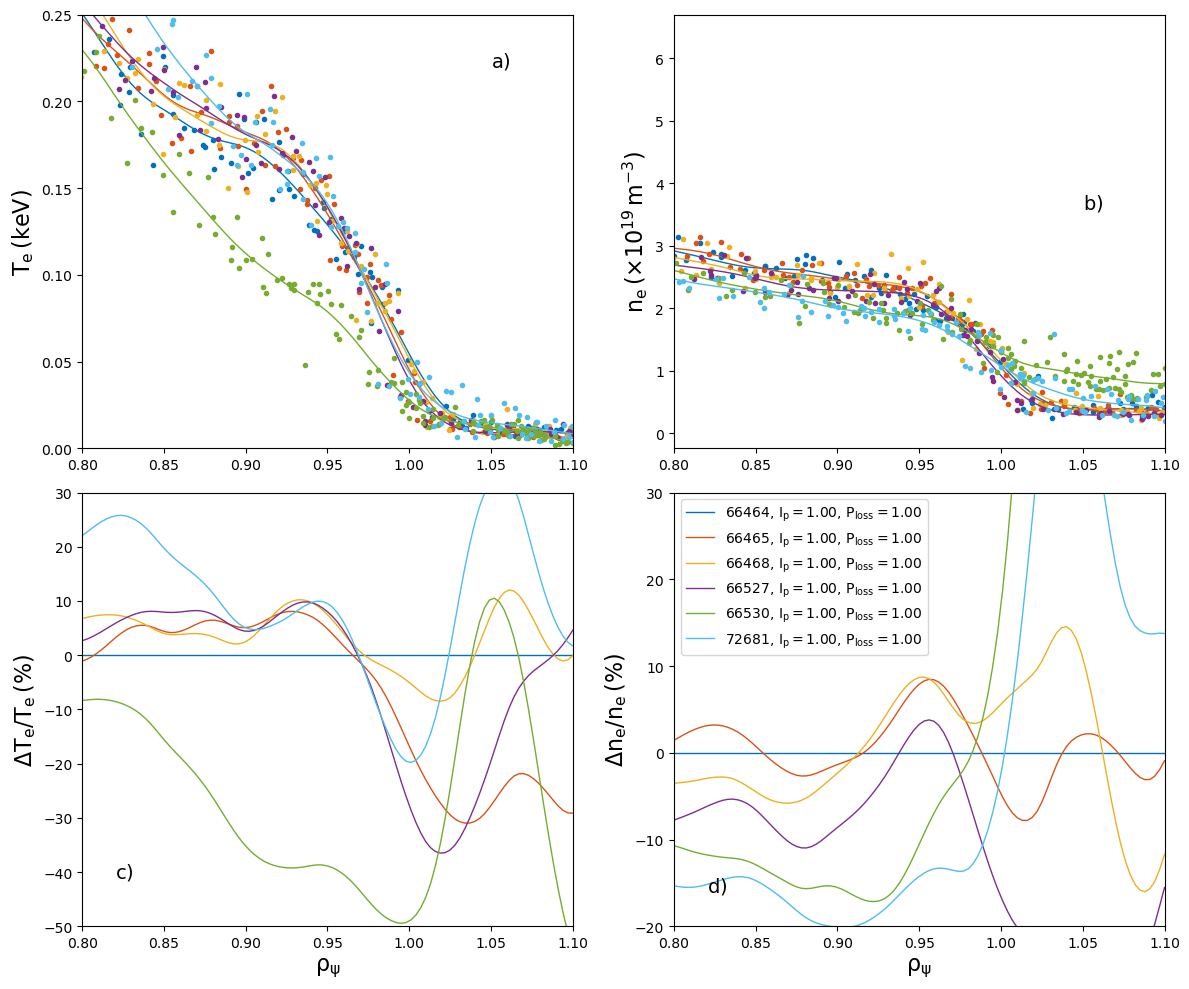

In [3]:
# Load data
filename = 'lhdatabase.h5'
with h5py.File(filename, 'r') as f:
    ILH = f['/ILH'][:]
    A = f['/A'][:]
    MDBTSM = f['/MDBTSM'][:]
    SEEDING = f['/SEEDING'][:]
    BAFFLES = f['/BAFFLES'][:]
    BT = f['/BT'][:]
    NEL20 = f['/NEL20'][:]
    cH = f['/cH'][:]
    MISSION = f['/MISSION'][:]
    Q95 = f['/Q95'][:]
    SHOT = f['/SHOT'][:]
    TIME = f['/TIME'][:]

# Apply conditions - equivalent to the boolean logic in MATLAB
# Note: In Python, & is element-wise "and", | is element-wise "or"
cond = (A == 2) & (SEEDING == 0) & (MDBTSM == 0.02) & (BAFFLES == 0) & (np.abs(BT) > 1.3) & (np.abs(BT) < 1.5)
cond = cond & (NEL20 > 0.37) & (NEL20 < 0.4)
cond = cond & (cH < 0.26)
cond = cond & (MISSION != 0)
cond = cond & (Q95 > 3.5)

# Extract filtered data
shn = SHOT[cond]      # Shot numbers
time = TIME[cond]     # Time points
index = np.where(cond)[0]  # Indices of matching conditions

# Load the pre-calculated data (equivalent to MATLAB's load m1943_fig8_data.mat)
# In Python, we use h5py to load from the HDF5 file
with h5py.File('LH_DATA.h5', 'r') as f:
    # Based on the user-provided structure
    dc = f['/data/fig8/dc'][:]  # Color data for plotting
    
    # Extract the pre-calculated xx0, xx1 values if available
    xx0 = f['/data/fig8/xxx0'][:].T
    xx1 = f['/data/fig8/xxx1'][:].T
    yy0 = f['/data/fig8/yyy0'][:].T
    yy1 = f['/data/fig8/yyy1'][:].T
    
    # Try to load IP and PLMW or use fallback values if not found
    try:
        IP = f.get('/IP')[:]
        PLMW = f.get('/PLMW')[:]
    except:
        print("Warning: IP and PLMW not found in h5 file. Using dummy values.")
        IP = np.ones(len(index))
        PLMW = np.ones(len(index))

# Create figure with 4 subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()  # Flatten to make indexing easier

# Initialize storage for interpolated data
data = {'fig8': {'tmp': [], 'tmp2': [], 'tmp2d': [], 'tmp3': [], 'tmp3d': []}}
strleg = []  # Legend strings

# Load all ts data once outside the loop for better performance
with h5py.File('LH_DATA.h5', 'r') as f:
    # Accessing the ts group according to the provided structure
    ts_data = {}
    for key in ['time', 'rho', 'te', 'dte', 'ne', 'dne']:
        try:
            ts_data[key] = f[f'/data/fig8/ts/{key}'][:]
        except:
            print(f"Warning: Could not find /data/fig8/ts/{key}, using empty array")
            ts_data[key] = np.array([])

# Process data for each shot - equivalent to the MATLAB for loop
for ii in range(len(shn)):
    
    # Extract data for the current time window
    with h5py.File('LH_DATA.h5', 'r') as f:
        tmp = f['/data/fig8/tmp'][:,ii] if ii < f['/data/fig8/tmp'].shape[0] else np.array([])
        tmp2 = f['/data/fig8/tmp2'][:,ii] if ii < f['/data/fig8/tmp2'].shape[0] else np.array([])
        tmp2d = f['/data/fig8/tmp2d'][:,ii] if ii < f['/data/fig8/tmp2d'].shape[0] else np.array([])
        tmp3 = f['/data/fig8/tmp3'][:,ii] if ii < f['/data/fig8/tmp3'].shape[0] else np.array([])
        tmp3d = f['/data/fig8/tmp3d'][:,ii] if ii < f['/data/fig8/tmp3d'].shape[0] else np.array([])
    
    # Process temperature data
    # Removing NaN values and sorting
    mask = ~np.isnan(tmp) & ~np.isnan(tmp2)
    x = tmp[mask]
    y = tmp2[mask]
    sorted_indices = np.argsort(x)
    x = x[sorted_indices]
    y = y[sorted_indices]
    
    # Calculate additional quantities - same as MATLAB
    tmp4 = tmp2 / 1e3 * tmp3 / 1e19 * 1.6
    
    # Get the proper color for this shot
    # The dc array is structured as (3×42) where each column represents RGB values
    color = dc[:, ii % (dc.shape[1])]  # Using modulo to prevent index errors
    
    # Plot temperature data - first subplot
    ax[0].plot(tmp, tmp2 / 1e3, '.', color=color)
    ax[0].plot(xx0[ii,:], yy0[ii,:], color=color, linewidth=1)
    
    # Store reference profile for first shot
    if ii == 0:
        ry = yy0[ii,:]
    
    # Plot relative temperature difference - third subplot
    ax[2].plot(xx0[ii,:], (yy0[ii,:] - ry) / ry * 100, color=color, linewidth=1)
    
    # Process density data - similar to temperature processing
    mask = ~np.isnan(tmp) & ~np.isnan(tmp3)
    x = tmp[mask]
    y = tmp3[mask]
    sorted_indices = np.argsort(x)
    x = x[sorted_indices]
    y = y[sorted_indices]
    
    # Plot density data - second subplot
    ax[1].plot(tmp, tmp3 / 1e19, '.', color=color)
    ax[1].plot(xx1[ii,:], yy1[ii,:], color=color, linewidth=1)
    
    # Store reference profile for first shot
    if ii == 0:
        ryn = yy1[ii,:]
    
    # Plot relative density difference - fourth subplot
    ax[3].plot(xx1[ii,:], (yy1[ii,:] - ryn) / ryn * 100, color=color, linewidth=1)
    
    # Create legend entry with proper formatting
    try:
        strleg.append(f"{int(shn[ii])}, $\\mathrm{{I_{{p}}=}}${IP[index[ii]]:.2f}, $\\mathrm{{P_{{loss}}=}}${PLMW[index[ii]]:.2f}")
    except:
        # Fallback if there's an issue
        strleg.append(f"{int(shn[ii]) if isinstance(shn[ii], (int, float)) else 'Shot'}")

# Set axes limits - same as MATLAB
ax[0].set_xlim([0.8, 1.1])
ax[1].set_xlim([0.8, 1.1])
ax[2].set_xlim([0.8, 1.1])
ax[3].set_xlim([0.8, 1.1])
ax[2].set_ylim([-50, 30])
ax[3].set_ylim([-20, 30])
ax[0].set_ylim([0, 0.25])

# Add text annotations - same as MATLAB but using raw strings for LaTeX
ax[0].text(1.05, 0.22, r'$\mathrm{a)}$', fontsize=14)
ax[1].text(1.05, 3.6, r'$\mathrm{b)}$', fontsize=14)
ax[2].text(0.82, -41, r'$\mathrm{c)}$', fontsize=14)
ax[3].text(0.82, -16, r'$\mathrm{d)}$', fontsize=14)

# Add axis labels - same as MATLAB but using raw strings for LaTeX
ax[2].set_xlabel(r'$\mathrm{\rho_\psi}$', fontsize=16)
ax[3].set_xlabel(r'$\mathrm{\rho_\psi}$', fontsize=16)
ax[0].set_ylabel(r'$\mathrm{T_e\,(keV)}$', fontsize=16)
ax[1].set_ylabel(r'$\mathrm{n_e\,(\times 10^{19}\,m^{-3})}$', fontsize=16)
ax[2].set_ylabel(r'$\mathrm{\Delta T_e/T_e\,(\%)}$', fontsize=16)
ax[3].set_ylabel(r'$\mathrm{\Delta n_e/n_e\,(\%)}$', fontsize=16)

# Add legend to the fourth subplot
ax[3].legend(strleg, loc='best')

# Adjust layout and save
plt.tight_layout()
plt.show()

* Figure 9

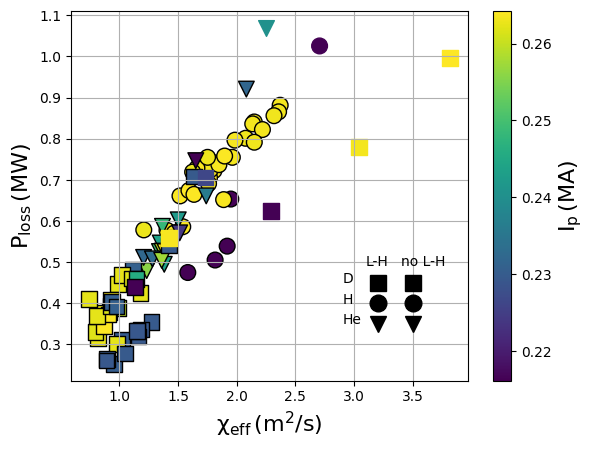

In [46]:
# Read HDF5 data
filename = 'lhdatabase.h5'
with h5py.File(filename, 'r') as f:
    ILH = f['/ILH'][:].astype(bool)
    A = f['/A'][:]
    PLMW = f['/PLMW'][:]
    IP = f['/IP'][:]
    CHIEFF = f['/CHIEFF'][:]
    COND = f['/COND'][:]  # Not used in plot

# Define axes
X = CHIEFF
Y = PLMW
Z = IP

plt.figure()

# ILH & A==1
cond = ILH & (A == 1)
h = plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='o', edgecolors='k')
# ~ILH & A==1
cond = ~ILH & (A == 1)
plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='o')

# ILH & A==4
cond = ILH & (A == 4)
plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='v', edgecolors='k')
# ~ILH & A==4
cond = ~ILH & (A == 4)
plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='v')
hc = plt.colorbar()

# ILH & A==2
cond = ILH & (A == 2)
plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='s', edgecolors='k')
# ~ILH & A==2
cond = ~ILH & (A == 2)
plt.scatter(X[cond], Y[cond], s=128, c=Z[cond], marker='s')

# Text annotations
plt.text(3.1, 0.49, 'L-H')
plt.text(3.4, 0.49, 'no L-H')
plt.text(2.9, 0.45, 'D')
plt.text(2.9, 0.4, 'H')
plt.text(2.9, 0.35, 'He')

# Marker legend
plt.plot(3.2, 0.45, 'sk', markersize=12, markerfacecolor='k')
plt.plot(3.5, 0.45, 'sk', markersize=12)
plt.plot(3.2, 0.4, 'ok', markersize=12, markerfacecolor='k')
plt.plot(3.5, 0.4, 'ok', markersize=12)
plt.plot(3.2, 0.35, 'vk', markersize=12, markerfacecolor='k')
plt.plot(3.5, 0.35, 'vk', markersize=12)

# Colormap
#cmap = plt.get_cmap('hsv')
#plt.set_cmap(cmap(np.linspace(0, 1, 56)))

# Formatting
plt.box(True)
plt.grid(True)
hc.set_label(r'$\mathrm{I_p\,(MA)}$', fontsize=16)
plt.ylabel(r'$\mathrm{P_{loss}\,(MW)}$', fontsize=16)
plt.xlabel(r'$\mathrm{\chi_{eff}\,(m^2/s)}$', fontsize=16)

plt.show()
